# EDA: Alpaca Cleaned Dataset

This notebook explores the dataset used for the project **Optimisation et compression des Small Language Models pour applications Edge AI**.

Scope:

- Load `yahma/alpaca-cleaned` from Hugging Face.
- Inspect columns, examples, missing values, and text lengths.
- Preview the instruction-tuning `source_text` and `target_text` format.
- Optionally inspect files created by `src/prepare_data.py` under `data/processed/`.

This notebook does **not** train, evaluate, or quantize a model.

## 1. Setup

In [1]:
from pathlib import Path
import json
import sys
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset


Matplotlib is building the font cache; this may take a moment.


In [2]:
def find_project_root():
    current = Path.cwd().resolve()
    if (current / "config.yaml").exists():
        return current
    if (current.parent / "config.yaml").exists():
        return current.parent
    raise FileNotFoundError("Could not find config.yaml. Run this notebook from the project root or notebooks/ folder.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import clean_text, load_config

PROJECT_ROOT

WindowsPath('D:/STUDY/OPTIMIZATION')

## 2. Load Configuration

In [3]:
config_path = PROJECT_ROOT / "config.yaml"
config = load_config(config_path)

dataset_name = config.get("data", {}).get("dataset_name", "yahma/alpaca-cleaned")
dataset_split = config.get("data", {}).get("dataset_split", "train")
processed_dir = PROJECT_ROOT / config.get("data", {}).get("processed_dir", "data/processed")
seed = config.get("seed", 42)

print(f"Dataset: {dataset_name}")
print(f"Split: {dataset_split}")
print(f"Seed: {seed}")
print(f"Processed directory: {processed_dir}")

Dataset: yahma/alpaca-cleaned
Split: train
Seed: 42
Processed directory: D:\STUDY\OPTIMIZATION\data\processed


## 3. Load Raw Dataset

In [4]:
raw_dataset = load_dataset(dataset_name, split=dataset_split)

print(raw_dataset)
print(f"Number of examples: {len(raw_dataset):,}")
print(f"Columns: {raw_dataset.column_names}")

README.md: 0.00B [00:00, ?B/s]

c:\Users\Othman SALAHI\.conda\envs\deep_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Othman SALAHI\.cache\huggingface\hub\datasets--yahma--alpaca-cleaned. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back 

alpaca_data_cleaned.json:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

Dataset({
    features: ['output', 'input', 'instruction'],
    num_rows: 51760
})
Number of examples: 51,760
Columns: ['output', 'input', 'instruction']


In [5]:
raw_df = raw_dataset.to_pandas()
raw_df[raw_df['input'] != '']

,output,input,instruction
6,The fraction 4/16 is equivalent to 1/4 because...,4/16,Explain why the following fraction is equivale...
8,There are two spelling errors in the sentence....,He finnished his meal and left the resturant,Evaluate this sentence for spelling and gramma...
13,Animals: Elephant\nPlants: Oak tree\nMinerals:...,"Oak tree, copper ore, elephant","Classify the following into animals, plants, a..."
16,```\n# This is a function that calculates the ...,def factorialize(num):\n factorial = 1\n for...,Refactor this code and add comments.
22,She will play the piano beautifully for hours ...,She played the piano beautifully for hours and...,"Based on the information provided, rewrite the..."
...,...,...,...
51755,Yes,Text: John went out for a walk with his dog Ro...,You will be given a piece of text about an eve...
51756,True,Text: Michael Jordan is an American former pro...,You will be given a paragraph of text with var...
51757,True,Text: A tree fell over in the wind and caused ...,You will be given a piece of text about an eve...
51758,Backwards,"Steps: ['She takes out her books', 'The teache...",I will give you a list of steps. You need to ...


## 4. Basic Structure and Missing Values

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51760 entries, 0 to 51759
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   output       51760 non-null  object
 1   input        51760 non-null  object
 2   instruction  51760 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB


In [7]:
fields = ["instruction", "input", "output"]

missing_summary = []
for field in fields:
    cleaned = raw_df[field].apply(clean_text)
    missing_summary.append(
        {
            "field": field,
            "missing_values": int(raw_df[field].isna().sum()),
            "empty_after_cleaning": int((cleaned == "").sum()),
            "non_empty_after_cleaning": int((cleaned != "").sum()),
        }
    )

pd.DataFrame(missing_summary)

,field,missing_values,empty_after_cleaning,non_empty_after_cleaning
0,instruction,0,0,51760
1,input,0,32603,19157
2,output,0,0,51760


## 5. Text Length Analysis

In [8]:
eda_df = raw_df.copy()

for field in fields:
    eda_df[field] = eda_df[field].apply(clean_text)
    eda_df[f"{field}_word_length"] = eda_df[field].apply(lambda text: len(text.split()))
    eda_df[f"{field}_char_length"] = eda_df[field].apply(len)

eda_df["has_input"] = eda_df["input"] != ""
eda_df[["instruction_word_length", "input_word_length", "output_word_length", "has_input"]].head()

,instruction_word_length,input_word_length,output_word_length,has_input
0,6,0,121,False
1,6,0,53,False
2,6,0,209,False
3,6,0,216,False
4,21,0,133,False


In [9]:
length_columns = [
    "instruction_word_length",
    "input_word_length",
    "output_word_length",
    "instruction_char_length",
    "input_char_length",
    "output_char_length",
]

eda_df[length_columns].describe().round(2)

,instruction_word_length,input_word_length,output_word_length,instruction_char_length,input_char_length,output_char_length
count,51760.00,51760.00,51760.00,51760.00,51760.00,51760.00
mean,10.54,4.19,109.94,62.38,24.23,673.89
std,6.65,11.71,103.20,38.56,70.76,643.61
min,2.00,0.00,1.00,9.00,0.00,1.00
25%,8.00,0.00,17.00,46.00,0.00,101.00
50%,10.00,0.00,80.00,57.00,0.00,473.00
75%,12.00,5.00,184.00,71.00,26.00,1126.00
max,323.00,475.00,507.00,2208.00,2634.00,3138.00


In [10]:
input_counts = eda_df["has_input"].value_counts().rename(index={True: "Has input", False: "No input"})
input_counts

has_input
No input     32603
Has input    19157
Name: count, dtype: int64

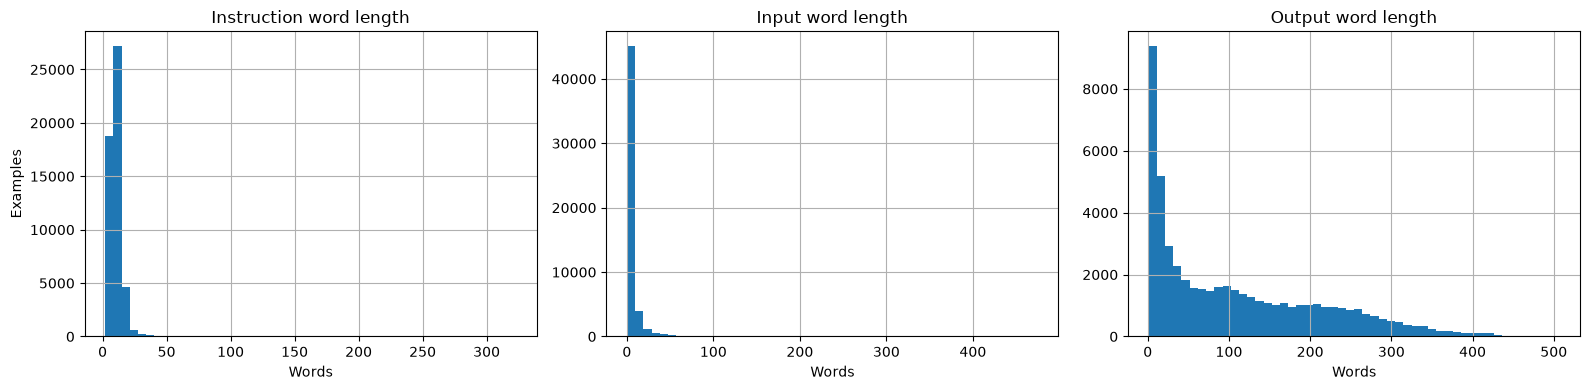

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

eda_df["instruction_word_length"].hist(bins=50, ax=axes[0])
axes[0].set_title("Instruction word length")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Examples")

eda_df["input_word_length"].hist(bins=50, ax=axes[1])
axes[1].set_title("Input word length")
axes[1].set_xlabel("Words")

eda_df["output_word_length"].hist(bins=50, ax=axes[2])
axes[2].set_title("Output word length")
axes[2].set_xlabel("Words")

plt.tight_layout()
plt.show()

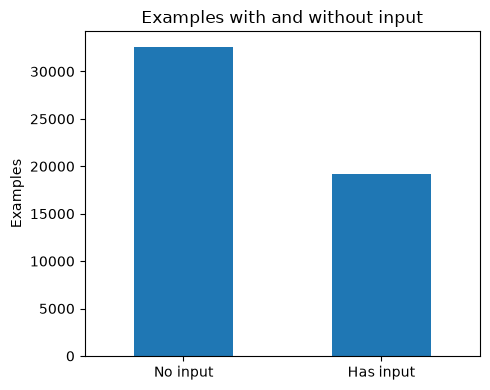

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
input_counts.plot(kind="bar", ax=ax)
ax.set_title("Examples with and without input")
ax.set_xlabel("")
ax.set_ylabel("Examples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Instruction-Tuning Format Preview

In [13]:
def build_source_text(instruction, input_text):
    if input_text:
        return f"Instruction: {instruction}\nInput: {input_text}\nAnswer:"
    return f"Instruction: {instruction}\nAnswer:"


def convert_for_instruction_tuning(row):
    instruction = clean_text(row.get("instruction", ""))
    input_text = clean_text(row.get("input", ""))
    output = clean_text(row.get("output", ""))
    source_text = build_source_text(instruction, input_text)

    return {
        "instruction": instruction,
        "input": input_text,
        "output": output,
        "source_text": source_text,
        "target_text": output,
        "source_length": len(source_text.split()),
        "target_length": len(output.split()),
    }


preview_rows = eda_df.sample(3, random_state=seed).to_dict(orient="records")
formatted_preview = [convert_for_instruction_tuning(row) for row in preview_rows]
pd.DataFrame(formatted_preview)[["source_text", "target_text", "source_length", "target_length"]]

,source_text,target_text,source_length,target_length
0,Instruction: How can you use technology to imp...,There are several ways technology can be used ...,12,262
1,"Instruction: Sort the numbers 15, 11, 9, 22.\n...","The sorted numbers in ascending order are: 9, ...",9,11
2,Instruction: Create a list of 8 questions to a...,1. What is your experience and educational bac...,13,103


In [14]:
example = formatted_preview[0]

print("SOURCE TEXT")
print("-----------")
print(example["source_text"])
print()
print("TARGET TEXT")
print("-----------")
print(example["target_text"])

SOURCE TEXT
-----------
Instruction: How can you use technology to improve your customer service?
Answer:

TARGET TEXT
-----------
There are several ways technology can be used to improve customer service, including the following: 1. Implementing Chatbots: Chatbots can help provide a faster, more personalized service to your customers. Equipped with artificial intelligence and natural language processing algorithms, chatbots can quickly respond to customer queries, saving customers time and providing them with immediate assistance. 2. Using Social Media: Using social media platforms to interact with customers is an excellent way to improve customer service. By maintaining an active presence on social media, companies can respond to messages and comments promptly, providing customers with an additional, convenient way to reach out for support. 3. Creating a customer-centered website: The company's website should be designed to provide customers with all the relevant information they nee

## 7. Optional: Inspect Prepared Files

In [15]:
processed_files = [
    "train.csv",
    "validation.csv",
    "test.csv",
    "train.jsonl",
    "validation.jsonl",
    "test.jsonl",
    "dataset_stats.json",
]

available_files = []
for file_name in processed_files:
    file_path = processed_dir / file_name
    available_files.append(
        {
            "file": file_name,
            "exists": file_path.exists(),
            "size_bytes": file_path.stat().st_size if file_path.exists() else 0,
        }
    )

pd.DataFrame(available_files)

,file,exists,size_bytes
0,train.csv,True,3134974
1,validation.csv,True,763792
2,test.csv,True,787329
3,train.jsonl,True,3358355
4,validation.jsonl,True,819623
5,test.jsonl,True,843053
6,dataset_stats.json,True,240


In [16]:
stats_path = processed_dir / "dataset_stats.json"

if stats_path.exists():
    with open(stats_path, "r", encoding="utf-8") as file:
        processed_stats = json.load(file)
    display(pd.DataFrame([processed_stats]).T.rename(columns={0: "value"}))
else:
    print("No processed statistics found yet. Run: python src/prepare_data.py")

,value
total_original_examples,51760.00
train_size,2000.00
validation_size,500.00
test_size,500.00
average_source_length,17.14
average_target_length,109.21
max_source_length,279.00
max_target_length,450.00


In [17]:
train_csv_path = processed_dir / "train.csv"

if train_csv_path.exists():
    prepared_train_df = pd.read_csv(train_csv_path)
    print(f"Prepared train rows: {len(prepared_train_df):,}")
    display(prepared_train_df.head())
else:
    print("No prepared train.csv found yet. Run: python src/prepare_data.py")

Prepared train rows: 2,000


,instruction,input,output,source_text,target_text,source_length,target_length
0,Rearrange the following sentence to make the s...,She left the party early,"Early, she left the party.",Instruction: Rearrange the following sentence ...,"Early, she left the party.",18,5
1,"Let f(x) = {[ -x - 3 if x ≤ 1,; x/2 + 1 if x >...",NaN,We solve the equation f(x) = 0 on the domains ...,"Instruction: Let f(x) = {[ -x - 3 if x ≤ 1,; x...",We solve the equation f(x) = 0 on the domains ...,34,91
2,Compose a haiku poem about a summer day.,NaN,Warm breeze on my face Endless sun brings joy ...,Instruction: Compose a haiku poem about a summ...,Warm breeze on my face Endless sun brings joy ...,10,15
3,What methods can be used to improve the accura...,NaN,Here are several methods to improve the accura...,Instruction: What methods can be used to impro...,Here are several methods to improve the accura...,15,217
4,Fill in the blanks to complete the sentence.,Global warming can be reversed by reducing ___...,Global warming can be reversed by reducing gre...,Instruction: Fill in the blanks to complete th...,Global warming can be reversed by reducing gre...,21,12


## 8. Key Takeaways Checklist

Use this section after running the notebook:

- Are `instruction`, `input`, and `output` fields mostly complete?
- How many examples include an extra `input` field?
- Are source and target lengths reasonable for `google/flan-t5-small`?
- Do the formatted `source_text` and `target_text` examples look correct?
- Do processed files exist after running `python src/prepare_data.py`?